In [23]:
import sys
sys.path.append("../src")

import time
import copy

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models

from dataset import (
    gather_samples, stratified_split, compute_class_weights,
    RiceLeafDataset, CLASSES
)

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [25]:
samples = gather_samples()
train_set, val_set, test_set = stratified_split(samples)
print("Train:", len(train_set), "Val:", len(val_set), "Test:", len(test_set))

class_weights = compute_class_weights(train_set)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights:", class_weights)

Train: 1927 Val: 413 Test: 413
Class weights: [0.6523358 1.3973894 0.9331719 0.5652684 1.591247  1.4800308 1.6484175]


In [26]:
BATCH_SIZE = 32
NUM_WORKERS = 4

train_ds = RiceLeafDataset(train_set, split="train")
val_ds = RiceLeafDataset(val_set, split="val")
test_ds = RiceLeafDataset(test_set, split="test")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("Batches - train/val/test:", len(train_loader), len(val_loader), len(test_loader))

Batches - train/val/test: 61 13 13


In [27]:
NUM_CLASSES = len(CLASSES)

model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, NUM_CLASSES)
model = model.to(device)

print(model.classifier)

Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True, bias=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=7, bias=True)
)


In [28]:
criterion = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

NUM_EPOCHS = 30
PATIENCE = 7

In [29]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [30]:
best_val_loss = float("inf")
best_model_wts = copy.deepcopy(model.state_dict())
epochs_no_improve = 0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    start = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
          f"time={elapsed:.1f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        torch.save(best_model_wts, "convnext_tiny_best.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_model_wts)
print("Best val_loss:", best_val_loss)

Epoch 1/30 | train_loss=1.3147 train_acc=0.5402 | val_loss=1.0193 val_acc=0.6077 | time=37.7s
Epoch 2/30 | train_loss=0.7617 train_acc=0.7431 | val_loss=0.8145 val_acc=0.6877 | time=41.2s
Epoch 3/30 | train_loss=0.5925 train_acc=0.7929 | val_loss=0.8508 val_acc=0.7094 | time=38.6s
Epoch 4/30 | train_loss=0.5159 train_acc=0.8282 | val_loss=0.8115 val_acc=0.7143 | time=38.3s
Epoch 5/30 | train_loss=0.4209 train_acc=0.8609 | val_loss=0.7922 val_acc=0.7409 | time=38.8s
Epoch 6/30 | train_loss=0.3705 train_acc=0.8744 | val_loss=0.8556 val_acc=0.7191 | time=38.2s
Epoch 7/30 | train_loss=0.3029 train_acc=0.9014 | val_loss=0.8305 val_acc=0.7361 | time=38.5s
Epoch 8/30 | train_loss=0.2378 train_acc=0.9133 | val_loss=0.8254 val_acc=0.7579 | time=38.6s
Epoch 9/30 | train_loss=0.2171 train_acc=0.9216 | val_loss=0.8775 val_acc=0.7651 | time=38.5s
Epoch 10/30 | train_loss=0.1847 train_acc=0.9445 | val_loss=0.8355 val_acc=0.7748 | time=38.5s
Epoch 11/30 | train_loss=0.1351 train_acc=0.9564 | val_loss

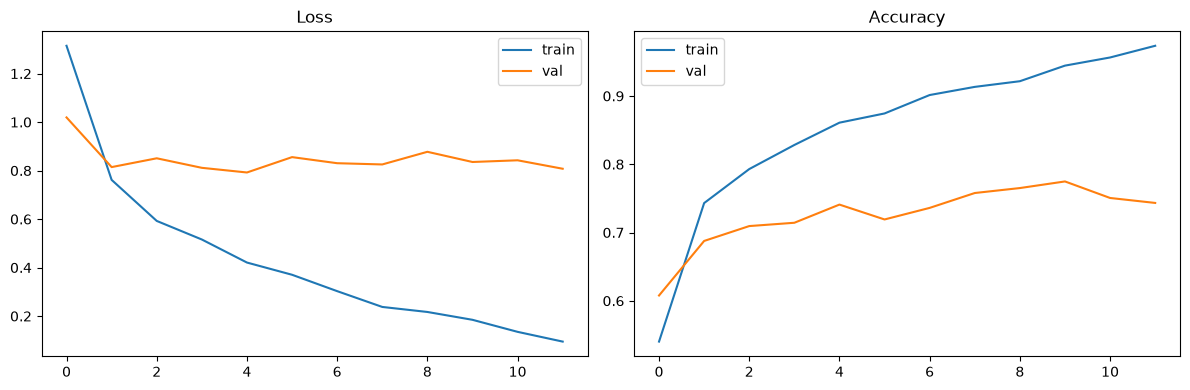

In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [32]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Macro-F1:", f1_score(all_labels, all_preds, average="macro"))
print(classification_report(all_labels, all_preds, target_names=CLASSES))
print("Confusion matrix:\n", confusion_matrix(all_labels, all_preds))

Macro-F1: 0.7214740889813538
                 precision    recall  f1-score   support

        Healthy       0.84      0.88      0.86        90
         Insect       0.81      0.81      0.81        42
     Leaf Scald       0.75      0.65      0.69        63
     Rice Blast       0.94      0.89      0.91       105
Rice Leaffolder       0.67      0.76      0.71        37
   Rice Stripes       0.46      0.42      0.44        40
    Rice Tungro       0.57      0.69      0.62        36

       accuracy                           0.77       413
      macro avg       0.72      0.73      0.72       413
   weighted avg       0.77      0.77      0.77       413

Confusion matrix:
 [[79  4  0  3  0  1  3]
 [ 3 34  2  0  1  2  0]
 [ 0  0 41  0  9  8  5]
 [ 3  0  2 93  1  2  4]
 [ 1  2  2  1 28  3  0]
 [ 2  2  7  2  3 17  7]
 [ 6  0  1  0  0  4 25]]


In [33]:
import time as _time

num_params = sum(p.numel() for p in model.parameters())
print("Total params:", num_params)

model.eval()
dummy = torch.randn(1, 3, 224, 224).to(device)
with torch.no_grad():
    for _ in range(5):
        model(dummy)
    start = _time.time()
    for _ in range(50):
        model(dummy)
    elapsed = _time.time() - start

print("Avg inference time (ms):", (elapsed / 50) * 1000)

Total params: 27825511
Avg inference time (ms): 5.589628219604492
